# Aprendizaje de Máquina I - Trabajo Práctico Final

**Integrantes**:
- Omar Victor Manuel Lopez Cabrera (a1609)
- Matías Alejandro Marando (a1615)
- Martin Omar Paz (a1109)

**Consigna**:
- El trabajo final de la cursada comprende de una investigación, desarrollo y resultados finales basados en un set de datos a elección por el grupo (máximo 6 personas).
- Los criterios de aprobación son los siguientes:
    - Obligación de trabajar en grupo mínimo de 2 y máximo de 6. Excepciones se pueden hacer mediante un correcto justificativo.
    - Cada TP debe citar la fuente de información de evaluación, es decir, citar de donde se obtuvieron los datos.
    - Puede ser entregado en cualquier formato, preferentemente en notebook de ipython (formato ipynb). También puede entregarse mediante un documento en Google Colab.
    - Contendrá la propuesta de investigación en los datos, citando el porqué de la evaluación y que se pretende encontrar o descubrir con dicha investigación
    - Deberá explicar el porqué de la elección del algoritmo empleado para la resolución del problema y cómo llegó a esa elección por sobre otras opciones
    - Deberá expresar de manera clara el resultado de la investigación aportando las métricas necesarias para comprender cómo se desempeña el algoritmo elegido.
    - El entregable debe venir con el código acompañado para su reproducibilidad.
    - En su cierre debe dar una reflexión de su investigación y proponer nuevos caminos de resolución en el caso de que sea necesario.
    - Como última fecha de entrega del trabajo, estará limitado a 7 días posteriores a la última clase.
    - La entrega es por el aula virtual, ya sea el envío del contenido o el link a repositorio (de GitHub o GitLab) con el trabajo.

-------------

## 1. Introducción y motivación

- **Fuente de información de evaluación**: Utilizaremos el dataset [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package), el cual comprende aproximadamente 10 años de observaciones diarias del clima en numerosos lugares de Australia.

- **Objetivo**: Queremos predecir si lloverá o no al día siguiente en función de datos meteorológicos del día actual, para integrar esta información en una aplicación meteorológica que beneficie al público.

- **Problema de negocio**: La predicción precisa de la lluvia es crucial para diversas actividades y sectores, como la agricultura, los viajes y la logística. La capacidad para anticipar la lluvia puede prevenir problemas y pérdidas financieras.

- **Enfoque**: Para abordar este problema utilizaremos técnicas de análisis de datos y machine learning para construir un modelo predictivo basado en el dataset disponible. Este modelo será validado y ajustado para asegurar su rendimiento y capacidad de generalización.

### Importación de librerías

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgboost
import time
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, accuracy_score, recall_score, balanced_accuracy_score, classification_report, make_scorer, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, plot_importance
import optuna

# Ajustar el número máximo de filas y columnas mostradas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

-------

## 2. Análisis exploratorio inicial

### Visualización de las primeras filas del dataset

In [86]:
# Cargamos el dataset (descargado de https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)
df = pd.read_csv("weatherAUS.csv")

# Visualizamos las primeras 5 filas
display(df.head())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Resumen de 5 números

In [87]:
five_number_summary = df.describe().loc[['min', '25%', '50%', '75%', 'max']]
display(five_number_summary)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,-8.5,-4.8,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,980.5,977.1,0.0,0.0,-7.2,-5.4
25%,7.6,17.9,0.0,2.6,4.8,31.0,7.0,13.0,57.0,37.0,1012.9,1010.4,1.0,2.0,12.3,16.6
50%,12.0,22.6,0.0,4.8,8.4,39.0,13.0,19.0,70.0,52.0,1017.6,1015.2,5.0,5.0,16.7,21.1
75%,16.9,28.2,0.8,7.4,10.6,48.0,19.0,24.0,83.0,66.0,1022.4,1020.0,7.0,7.0,21.6,26.4
max,33.9,48.1,371.0,145.0,14.5,135.0,130.0,87.0,100.0,100.0,1041.0,1039.6,9.0,9.0,40.2,46.7


Observaciones:
- Temperatura: Los valores de temperatura oscilan en un rango amplio, con temperaturas mínimas extremadamente bajas (-8.5°C) y máximas muy altas (48.1°C).
- Precipitación: La mayoría de los días no presenta lluvia (percentiles 25% y 50% en 0 mm), pero hay algunos eventos extremos con hasta 371 mm de lluvia en un solo día.
- Evaporación y horas de sol: Sus valores también varían considerablemente, lo que indica diferentes condiciones climáticas en las ubicaciones y fechas registradas.
- Velocidad del Viento: La velocidad del viento muestra una variabilidad significativa, con ráfagas de viento que pueden llegar hasta 135 km/h.
- Humedad: La humedad relativa también presenta una amplia dispersión, desde condiciones muy secas hasta niveles de humedad completa (100%).
- Presión atmosférica: La presión varía en un rango normal, pero hay diferencias notables entre los mínimos y máximos observados.
- Nubosidad: La nubosidad varía desde cielos despejados hasta completamente nublados. El rango debería ser de 0 a 8 y hay algunas observaciones que valen 9 que deberían tratarse como outliers.

En general, el resumen muestra una gran variabilidad climática en las diferentes ubicaciones y tiempos en Australia, lo cual es típico dada la diversidad geográfica y climática del país.

### Identificación de los tipos de datos

| Variable        | Tipo de variable | Tipo de dato | Subcategoría   |Informativa | Descripción             |
|-----------------|------------|--------------|----------|-------------|---------------------------------------------------|
| Date            | Fecha      | Fecha        |          | Sí          | Fecha del registro de los datos.                                            |
| Location        | Categórica | Cualitativa  |          | Sí          | Nombre de la ciudad en Australia.                                           |
| MinTemp         | Numérica   | Cuantitativa | Continua | Sí          | Temperatura mínima durante un día en particular. (grados Celsius)           |
| MaxTemp         | Numérica   | Cuantitativa | Continua | Sí          | Temperatura máxima durante un día en particular. (grados Celsius)           |
| Rainfall        | Numérica   | Cuantitativa | Continua | Sí          | Precipitación durante un día en particular. (milímetros)                    |
| Evaporation     | Numérica   | Cuantitativa | Continua | Sí          | Evaporación durante un día en particular. (milímetros)                      |
| Sunshine        | Numérica   | Cuantitativa | Continua | Sí          | Horas de sol durante un día en particular. (horas)                          |
| WindGustDir     | Categórica | Cualitativa  |          | Sí          | Dirección de la ráfaga de viento más fuerte durante un día. (16 puntos cardinales) |
| WindGustSpeed   | Numérica   | Cuantitativa | Continua | Sí          | Velocidad de la ráfaga de viento más fuerte durante un día. (kilómetros por hora) |
| WindDir9am      | Categórica | Cualitativa  |          | Sí          | Dirección del viento durante los 10 minutos previos a las 9 am. (puntos cardinales) |
| WindDir3pm      | Categórica | Cualitativa  |          | Sí          | Dirección del viento durante los 10 minutos previos a las 3 pm. (puntos cardinales) |
| WindSpeed9am    | Numérica   | Cuantitativa | Continua | Sí          | Velocidad del viento durante los 10 minutos previos a las 9 am. (kilómetros por hora) |
| WindSpeed3pm    | Numérica   | Cuantitativa | Continua | Sí          | Velocidad del viento durante los 10 minutos previos a las 3 pm. (kilómetros por hora) |
| Humidity9am     | Numérica   | Cuantitativa | Continua | Sí          | Humedad del aire a las 9 am. (porcentaje)                                   |
| Humidity3pm     | Numérica   | Cuantitativa | Continua | Sí          | Humedad del aire a las 3 pm. (porcentaje)                                   |
| Pressure9am     | Numérica   | Cuantitativa | Continua | Sí          | Presión atmosférica a las 9 am. (hectopascales)                             |
| Pressure3pm     | Numérica   | Cuantitativa | Continua | Sí          | Presión atmosférica a las 3 pm. (hectopascales)                             |
| Cloud9am        | Numérica   | Cuantitativa | Discreta | Sí          | Parte del cielo cubierto por nubes a las 9 am. (octavos)                    |
| Cloud3pm        | Numérica   | Cuantitativa | Discreta | Sí          | Parte del cielo cubierto por nubes a las 3 pm. (octavos)                    |
| Temp9am         | Numérica   | Cuantitativa | Continua | Sí          | Temperatura a las 9 am. (grados Celsius)                                    |
| Temp3pm         | Numérica   | Cuantitativa | Continua | Sí          | Temperatura a las 3 pm. (grados Celsius)                                    |
| RainToday       | Categórica | Cualitativa  |          | Sí          | Si hoy llueve, entonces 'Sí'. Si hoy no llueve, entonces 'No'.              |
| RainTomorrow    | Categórica | Cualitativa  |          | Sí          | Si mañana llueve, entonces 'Sí'. Si mañana no llueve, entonces 'No'.        |

--------
### Análisis de las variables numéricas

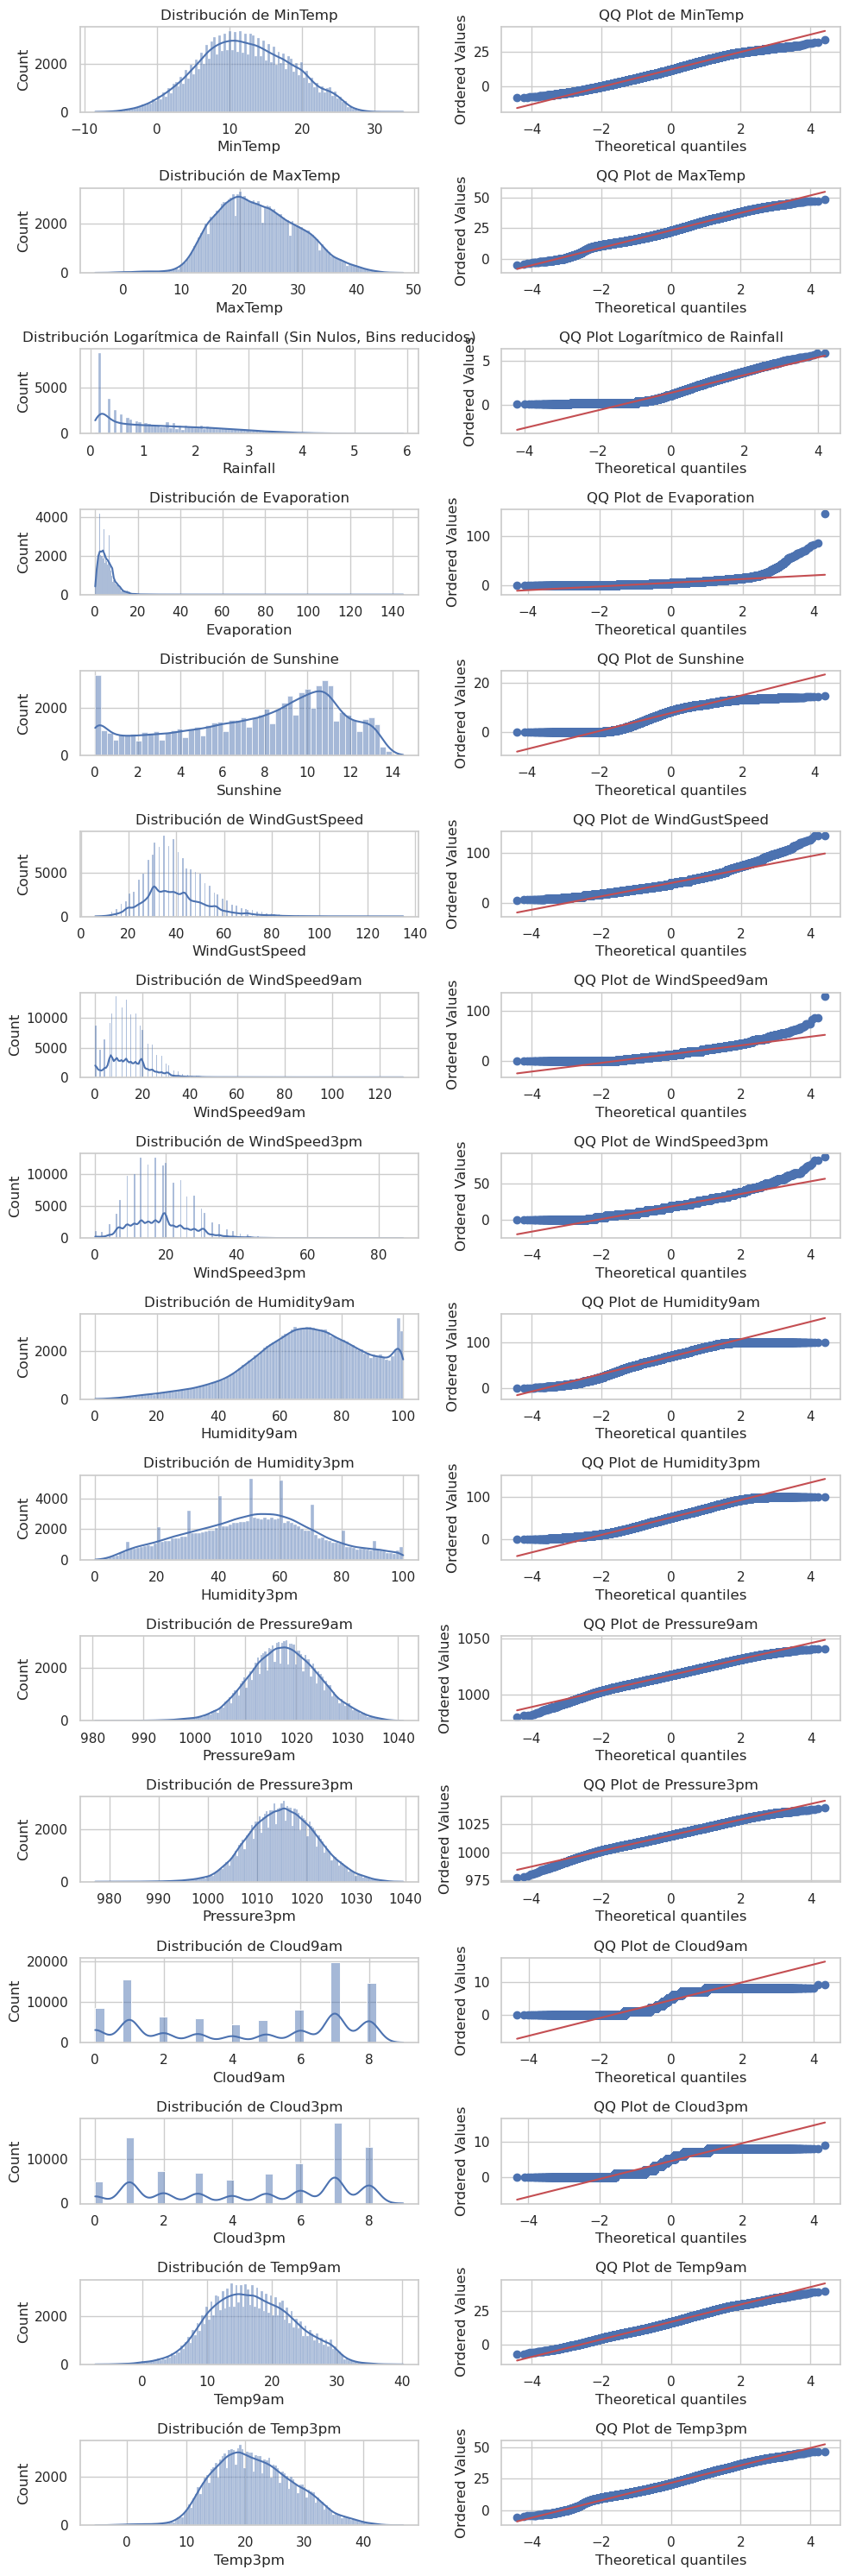

In [88]:
# Configuración de los gráficos
sns.set(style="whitegrid")
plt.figure(figsize=(10, 30))

# Histograma y QQ plot para cada variable numérica
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

for i, column in enumerate(numerical_columns, 1):
    # Histograma
    plt.subplot(len(numerical_columns), 2, 2*i-1)

    if column == 'Rainfall':
        # Modificaciones para Rainfall
        data = np.log1p(df[column].dropna()[df[column] > 0])
        sns.histplot(data, bins=100, kde=True)
        plt.title(f'Distribución Logarítmica de {column} (Sin Nulos, Bins reducidos)')
    else:
        # Para las otras variables
        sns.histplot(df[column].dropna(), kde=True)
        plt.title(f'Distribución de {column}')

    # QQ plot
    plt.subplot(len(numerical_columns), 2, 2*i)

    if column == 'Rainfall':
        stats.probplot(data, dist="norm", plot=plt)
        plt.title(f'QQ Plot Logarítmico de {column}')
    else:
        stats.probplot(df[column].dropna(), dist="norm", plot=plt)
        plt.title(f'QQ Plot de {column}')

plt.tight_layout()
plt.show()

Observaciones:
- **Distribución Normal**: `MinTemp, MaxTemp, Temp9am, Temp3pm, Pressure9am, Pressure3pm`
    * Estas variables parecen seguir una distribución aproximadamente normal, aunque con algunas desviaciones en los extremos, especialmente visible en los QQ plots, donde los puntos se desvían de la línea roja en los cuartiles extremos.

- **Distribuciones Sesgadas**: `Rainfall, Evaporation, WindSpeed9am, WindSpeed3pm, Cloud9am, Cloud3pm`
    * `Rainfall` y `Evaporation` muestran una fuerte asimetría con colas largas a la derecha, lo que es típico de variables que pueden tener valores extremos (outliers).
    * `WindSpeed9am` y `WindSpeed3pm` también tienen distribuciones sesgadas pero los valores bajos son más frecuentes.

- **Distribuciones con Formas Complejas**: `Sunshine, Humidity9am, Humidity3pmn`
    * `Sunshine` tiene una distribución bimodal, lo que sugiere que hay dos grupos de datos distintos. Esto puede estar relacionado con diferentes patrones de luz solar en diferentes regiones o estaciones.
    * Las distribuciones de `Humidity9am` y `Humidity3pm` presentan picos pronunciados, especialmente cerca del 100%, lo cual podría indicar que hay días o regiones con alta saturación de humedad.

La mayoría de los QQ plots muestran desviaciones de la normalidad en las colas, lo que indica que los datos contienen valores extremos o están sesgados.

--------
### Análisis de las variables categóricas

In [89]:
# Convertimos la columna 'Date' a formato de fecha
df['Date'] = pd.to_datetime(df['Date'])

# Extraemos solo la fecha (sin la parte de la hora)
df['Date'] = df['Date'].dt.date

# Identificamos las variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns.tolist())


['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


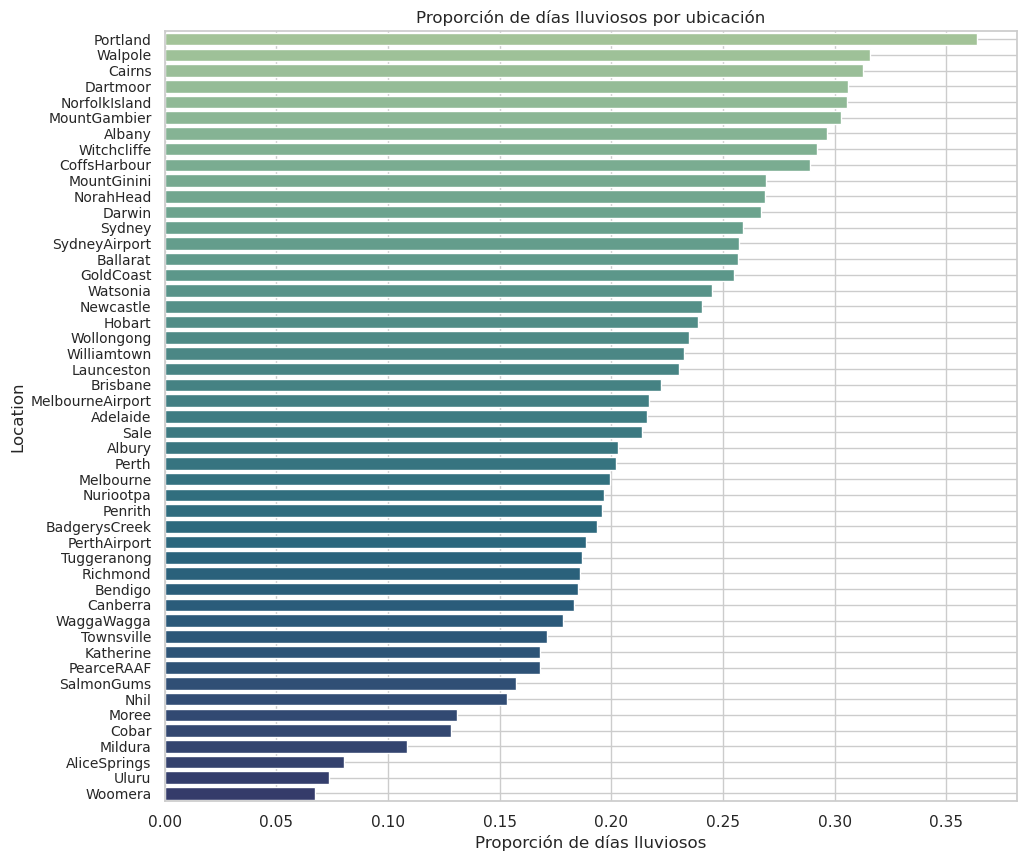

In [90]:
# Gráfico de barras horizontales para la proporción de días lluviosos por ubicación
total_days_count = df['Location'].value_counts()
rainy_days_count = df[df['RainToday'] == 'Yes']['Location'].value_counts()
rainy_days_ratio = (rainy_days_count / total_days_count).fillna(0)

rainy_days_df = pd.DataFrame({
    'Location': rainy_days_ratio.index,
    'RainyDaysRatio': rainy_days_ratio.values
})
rainy_days_df = rainy_days_df.sort_values(by='RainyDaysRatio', ascending=False)

plt.figure(figsize=(11, 10))
sns.barplot(y='Location', x='RainyDaysRatio', data=rainy_days_df, hue='Location', palette='crest')
plt.title('Proporción de días lluviosos por ubicación')
plt.xlabel('Proporción de días lluviosos')
plt.ylabel('Location')
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()

Vemos que hay una gran variabilidad en la proporción de días lluviosos y la temperatura según la ubicación.

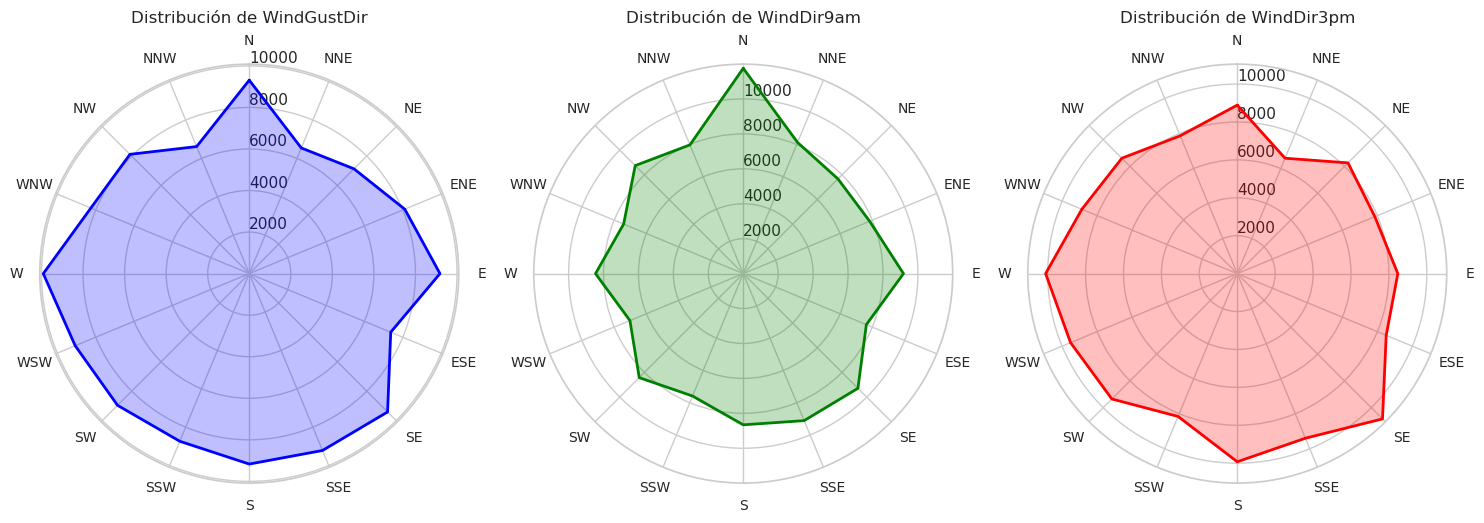

In [91]:
# Gráficos polares para las direcciones del viento
# Calcular frecuencias por dirección del viento
wind_dirs = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
wind_dir_gust = df['WindGustDir'].value_counts().reindex(wind_dirs).fillna(0)
wind_dir_9am = df['WindDir9am'].value_counts().reindex(wind_dirs).fillna(0)
wind_dir_3pm = df['WindDir3pm'].value_counts().reindex(wind_dirs).fillna(0)

# Crear el gráfico polar
plt.figure(figsize=(15, 5))

# Gráfico para WindGustDir
plt.subplot(1, 3, 1, polar=True)
angles = np.linspace(0, 2 * np.pi, len(wind_dirs), endpoint=False).tolist()
wind_stats = wind_dir_gust.values
wind_stats = np.concatenate((wind_stats, [wind_stats[0]]))
angles += angles[:1]
plt.fill(angles, wind_stats, color='blue', alpha=0.25)
plt.plot(angles, wind_stats, color='blue', linewidth=2)
plt.title('Distribución de WindGustDir', va='bottom')
plt.xticks(angles[:-1], wind_dirs, fontsize=10)
plt.gca().set_theta_zero_location('N')
plt.gca().set_theta_direction(-1)
plt.gca().set_rlabel_position(0)

# Gráfico para WindDir9am
plt.subplot(1, 3, 2, polar=True)
wind_stats = wind_dir_9am.values
wind_stats = np.concatenate((wind_stats, [wind_stats[0]]))
plt.fill(angles, wind_stats, color='green', alpha=0.25)
plt.plot(angles, wind_stats, color='green', linewidth=2)
plt.title('Distribución de WindDir9am', va='bottom')
plt.xticks(angles[:-1], wind_dirs, fontsize=10)
plt.gca().set_theta_zero_location('N')
plt.gca().set_theta_direction(-1)
plt.gca().set_rlabel_position(0)

# Gráfico para WindDir3pm
plt.subplot(1, 3, 3, polar=True)
wind_stats = wind_dir_3pm.values
wind_stats = np.concatenate((wind_stats, [wind_stats[0]]))
plt.fill(angles, wind_stats, color='red', alpha=0.25)
plt.plot(angles, wind_stats, color='red', linewidth=2)
plt.title('Distribución de WindDir3pm', va='bottom')
plt.xticks(angles[:-1], wind_dirs, fontsize=10)
plt.gca().set_theta_zero_location('N')
plt.gca().set_theta_direction(-1)
plt.gca().set_rlabel_position(0)

plt.tight_layout()
plt.show()

/simdata/mmarando/tmp/ipykernel_28217/2737891238.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.xticks(pd.date_range(start=rain_today_proportions.index.min(),
/simdata/mmarando/tmp/ipykernel_28217/2737891238.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start=rain_today_proportions.index.min(),


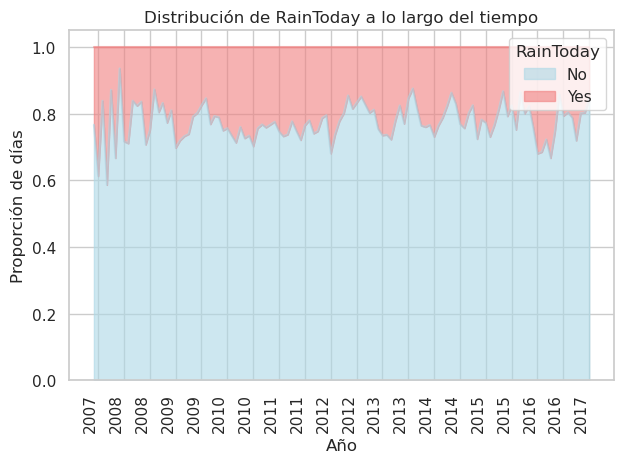

In [92]:
# Proporción de RainToday por mes a lo largo del tiempo
df_raintoday = df.copy()
df_raintoday['Date'] = pd.to_datetime(df['Date'])
df_raintoday['YearMonth'] = df_raintoday['Date'].dt.to_period('M')
rain_today_counts = df_raintoday.groupby(['YearMonth', 'RainToday']).size().unstack().fillna(0)
rain_today_proportions = rain_today_counts.div(rain_today_counts.sum(axis=1), axis=0)
rain_today_proportions.index = rain_today_proportions.index.to_timestamp()

sns.set(style="whitegrid")
rain_today_proportions.plot(kind='area', stacked=True, color=['lightblue', 'lightcoral'], alpha=0.6)
plt.title('Distribución de RainToday a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Proporción de días')
plt.legend(title='RainToday', loc='upper right')
plt.xticks(rotation=90)

plt.grid(True)
plt.xticks(pd.date_range(start=rain_today_proportions.index.min(),
                         end=rain_today_proportions.index.max(), freq='6M'),
           pd.date_range(start=rain_today_proportions.index.min(),
                         end=rain_today_proportions.index.max(), freq='6M').strftime('%Y'))

plt.tight_layout()
plt.show()

--------
### Análisis de las fechas

In [93]:
# Análisis básico de 'Date'
# Convertir la columna 'Date' a tipo datetime
print("Tamaño de df['Date']:", df['Date'].size)
df_temp = df.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='%Y-%m-%d')

# Crear una nueva columna 'Year' para almacenar el año
df_temp['Year'] = df_temp['Date'].dt.year

# Ordenar el DataFrame por la columna 'Year' en orden ascendente
df_temp = df_temp.sort_values(by='Year', ascending=True)

# Reiniciar los índices si es necesario
df_temp = df_temp.reset_index(drop=True)

# Reiniciar los índices si es necesario
df_temp = df_temp.reset_index(drop=True)
print("Fecha inicial:", df_temp['Date'].min())
print("Fecha final:", df_temp['Date'].max())
print("Número de fechas únicas:", df_temp['Date'].nunique())
print("Fechas repetidas:", df_temp['Date'].duplicated().sum())

Tamaño de df['Date']: 145460
Fecha inicial: 2007-11-01 00:00:00
Fecha final: 2017-06-25 00:00:00
Número de fechas únicas: 3436
Fechas repetidas: 142024


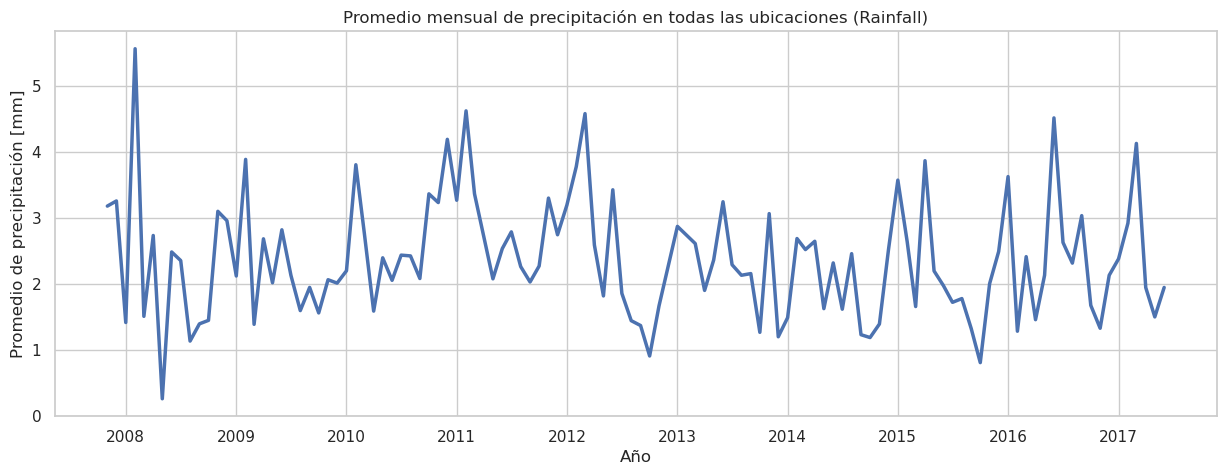

In [94]:
# Promedio del rainfall para todas las ubicaciones por mes
df_temp['YearMonth'] = df_temp['Date'].dt.to_period('M')
monthly_avg_rainfall = df_temp.groupby('YearMonth')['Rainfall'].mean().reset_index()
monthly_avg_rainfall['YearMonth'] = monthly_avg_rainfall['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(15, 5))
sns.set(style="whitegrid")
sns.lineplot(x='YearMonth', y='Rainfall', data=monthly_avg_rainfall, linewidth=2.5)
plt.title('Promedio mensual de precipitación en todas las ubicaciones (Rainfall)')
plt.xlabel('Año')
plt.ylabel('Promedio de precipitación [mm]')
plt.grid(True)
plt.show()

Se puede ver que tiene una especie de comportamiento cíclico en cuanto a la cantidad de agua que cae año a año. En donde cae más a principio de año (epoca de lluvia en australia).

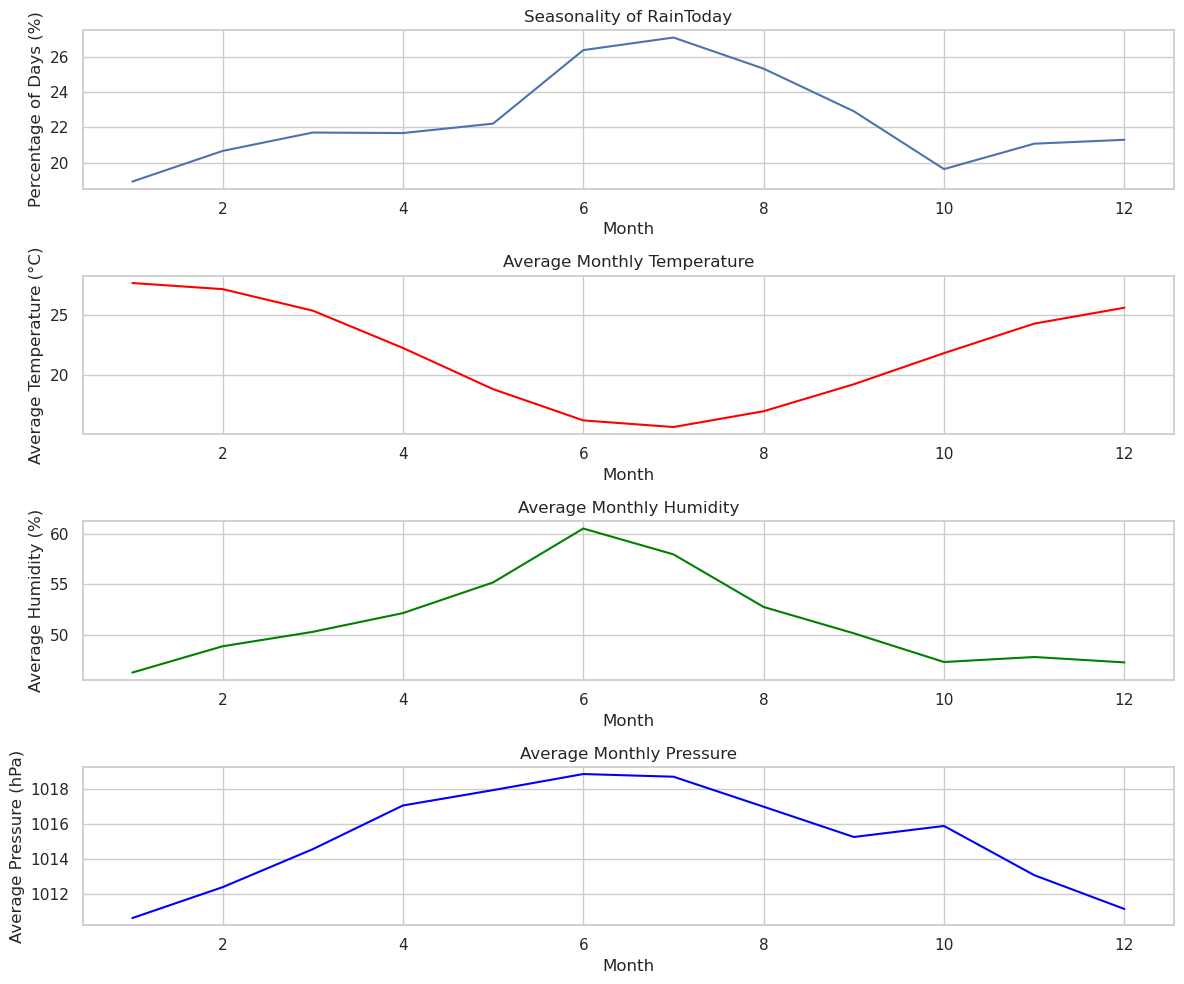

In [95]:
# Copia el dataframe
df_seasonality = df.copy()

# Elimina los nulos de la columna RainToday
df_seasonality = df_seasonality.dropna(subset=['RainToday'])

# Extrae el mes de la fecha
df_seasonality['Month'] = df_seasonality['Date'].apply(lambda x: int(str(x)[5:7]))

# Mapea RainToday a valores numéricos
df_seasonality['RainToday_numeric'] = df_seasonality['RainToday'].map({'Yes': 1, 'No': 0})

# Agrupa por mes y calcula la proporción de días con lluvia y sin lluvia
df_seasonality_grouped = df_seasonality.groupby('Month')['RainToday'].value_counts(normalize=True).unstack()

# Convertir la proporción a porcentaje
df_seasonality_grouped = df_seasonality_grouped * 100

# Agrupación por mes y cálculo de promedios
df_avg = df_seasonality.groupby('Month').agg({
    'Temp3pm': 'mean',
    'Humidity3pm': 'mean',
    'Pressure3pm': 'mean'
}).reset_index()

# Configuración de la figura con subplots
plt.figure(figsize=(12, 10))

# Gráfico de estacionalidad para días con lluvia
plt.subplot(4, 1, 1)
sns.lineplot(data=df_seasonality_grouped, x=df_seasonality_grouped.index, y='Yes')
plt.title('Seasonality of RainToday')
plt.xlabel('Month')
plt.ylabel('Percentage of Days (%)')
plt.tight_layout()

# Gráfico para la temperatura
plt.subplot(4, 1, 2)
sns.lineplot(data=df_avg, x='Month', y='Temp3pm', color='red')
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.tight_layout()

# Gráfico para la humedad
plt.subplot(4, 1, 3)
sns.lineplot(data=df_avg, x='Month', y='Humidity3pm', color='green')
plt.title('Average Monthly Humidity')
plt.xlabel('Month')
plt.ylabel('Average Humidity (%)')
plt.tight_layout()

# Gráfico para la presión
plt.subplot(4, 1, 4)
sns.lineplot(data=df_avg, x='Month', y='Pressure3pm', color='blue')
plt.title('Average Monthly Pressure')
plt.xlabel('Month')
plt.ylabel('Average Pressure (hPa)')
plt.tight_layout()

# Mostrar todos los gráficos
plt.show()


Se puede observar que tiene un comportamiento cícliclo por estación, por lo que sería recomendables tener features de month y season.

--------
### Análisis de las variables de salida

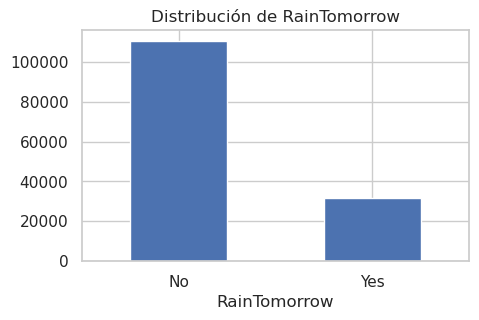

In [96]:
# Gráfico de barras para 'RainTomorrow'
plt.figure(figsize=(5, 3))
df['RainTomorrow'].value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.xticks(rotation=0)
plt.show()

- La variable target `RainTomorrow` está desbalanceada, la clase 'No' (no lloverá) es significativamente más frecuente que la clase 'Yes' (lloverá).
- Es una variable categórica binaria así que `Yes` se codificará como `1` y `No` como `0`.

----------
## 3. Limpieza y preparación de datos / ingeniería de features

### Datos faltantes

In [97]:
# Cantidad de observaciones y valores faltantes
num_observaciones = df.shape[0]
print(f'Número de observaciones: {num_observaciones}')

valores_faltantes = df.isna().sum()
porcentaje_faltantes = ((valores_faltantes / num_observaciones) * 100).round(1)
display(pd.DataFrame({
    'Cantidad Faltantes': valores_faltantes,
    'Porcentaje Faltantes': porcentaje_faltantes
}))

Número de observaciones: 145460


,Cantidad Faltantes,Porcentaje Faltantes
Date,0,0.0
Location,0,0.0
MinTemp,1485,1.0
MaxTemp,1261,0.9
Rainfall,3261,2.2
Evaporation,62790,43.2
Sunshine,69835,48.0
WindGustDir,10326,7.1
WindGustSpeed,10263,7.1
WindDir9am,10566,7.3


- `Date` y `Location` no tienen valores faltantes, lo que indica que todas las entradas tienen una fecha y una ubicación asociada.
- `Evaporation`, `Sunshine`, `Cloud9am` y `Cloud3pm` tienen un gran número de valores faltantes, podría ser un indicador de que estas variables son difíciles de medir o no están siempre disponibles
- Las otras variables tienen valores faltantes entre 1 y 7% del total de observaciones

Supuestos sobre los datos faltantes:
- Datos faltantes no aleatorios (MNAR): Algunos datos podrían estar ausentes debido a la imposibilidad de medición en ciertas condiciones climáticas. Por ejemplo, la `Evaporation` o `Sunshine` podrían estar ausentes en días de lluvia intensa.
- Datos faltantes aleatorios (MAR o MCAR): Es posible que algunos valores estén ausentes de manera aleatoria debido a errores de registro o fallos en los sensores. Por ejemplo, el `WindGustDir` o `Pressure9am` podrían estar faltantes en un día particular sin un patrón específico.

Técnicas de imputación recomendadas:
- Imputación por Media/Mediana/Moda: útil para los datos numéricos con un bajo porcentaje de datos faltantes.
- Imputación por K-Nearest Neighbors (KNN): útil cuando los datos tienen una estructura de correlación.
- Imputación múltiple (MICE): útil si hay múltiples variables con valores faltantes y existe una correlación significativa entre ellas

In [98]:
# Filtrar solo las columnas necesarias
columns_of_interest = ['Location', 'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'Pressure9am', 'Pressure3pm']
df_filtered = df[columns_of_interest]

# Calcular el número de faltantes por Location
missing_data_location = df_filtered.isna().groupby(df['Location']).sum()

# Calcular el total de datos por Location
total_data_location = df_filtered.groupby(df['Location']).size()

# Convertir total_data_location a numpy array para la operación de división
total_data_location_array = total_data_location.values

# Calcular el porcentaje de faltantes
percentage_missing_location = (missing_data_location.div(total_data_location_array, axis=0) * 100).round(2)

# Unir la información de número y porcentaje de faltantes
missing_data_location['Total Observations'] = total_data_location
result = pd.concat([missing_data_location, percentage_missing_location.rename(columns=lambda x: x + ' (%)')], axis=1)

result.drop(columns=['Location', 'Location (%)'], inplace=True)

# Mostrar el resultado
display(result)

,Evaporation,Sunshine,Cloud9am,Cloud3pm,Pressure9am,Pressure3pm,Total Observations,Evaporation (%),Sunshine (%),Cloud9am (%),Cloud3pm (%),Pressure9am (%),Pressure3pm (%)
Location,,,,,,,,,,,,,
Adelaide,1489,1424,3193,3193,8,7,3193,46.63,44.60,100.00,100.00,0.25,0.22
Albany,290,520,38,711,25,25,3040,9.54,17.11,1.25,23.39,0.82,0.82
Albury,3040,3040,1751,1613,5,8,3040,100.00,100.00,57.60,53.06,0.16,0.26
AliceSprings,215,520,334,361,1,3,3040,7.07,17.11,10.99,11.88,0.03,0.10
BadgerysCreek,3009,3009,3009,3009,168,173,3009,100.00,100.00,100.00,100.00,5.58,5.75
Ballarat,3040,3040,546,1048,24,26,3040,100.00,100.00,17.96,34.47,0.79,0.86
Bendigo,1855,3040,968,772,15,10,3040,61.02,100.00,31.84,25.39,0.49,0.33
Brisbane,19,49,1,2,1,8,3193,0.60,1.53,0.03,0.06,0.03,0.25
Cairns,370,476,207,230,1,0,3040,12.17,15.66,6.81,7.57,0.03,0.00


La tabla muestra la cantidad de missings para cada ubicación en valor absoluto y en %. Se observa que hay lugares en los que faltan muchos datos, podría ser porque no tienen los sensores y/o se limitaron solo a ver si llueve o no. Esos lugares se pueden eliminar o imputar con los valores de los lugares cercanos.

----
###  Feature engineering 

In [99]:
# Creamos nuevas variables que puedan aportar informacion extra
def create_weather_features(df):
    df = df.copy()

    # Convertir la columna 'Date' a datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Crear la columna 'Month'
    df['Month'] = df['Date'].dt.month

    # Función para determinar la estación
    def get_season_weighted(month):
        if month in [3, 4, 5]:
            return 0.5
        elif month in [6, 7, 8]:
            return -1
        elif month in [9, 10, 11]:
            return -0.5
        else:
            return 1

    # Crear la columna Season usando la función get_season_weighted
    df['Season'] = df['Month'].apply(get_season_weighted)

    # Crear variables para la diferencia de temperatura entre la maxima y la minima
    # y para la diferencia de humedad entre la maxima y la minima
    df['Temp_diff'] = df['MaxTemp'] - df['MinTemp']
    df['Humidity_diff'] = df['Humidity3pm'] - df['Humidity9am']

    # Crear una variable que sea el producto de la humedad y la temperatura para capturar situaciones
    # donde hay alta humedad y altas temperaturas que pueden llevar a la formación de tormentas.
    df['HumTemp'] = df['Humidity3pm'] * df['Temp3pm']

    # Una interacción entre la presión y la temperatura podría ayudar a modelar situaciones específicas
    # que promueven la lluvia
    df['PressTemp'] = df['Pressure3pm'] * df['Temp3pm']

    # Suma Acumulada de Lluvia en los últimos 3 días.
    df['Rainfall_last_3_days'] = df['Rainfall'].rolling(window=3).sum().bfill()

    # Promedio de lluvia en los últimos 7 días.
    df['Avg_Rainfall_last_7_days'] = df['Rainfall'].rolling(window=7).mean().bfill()

    # Suma Acumulada de Horas de Sol en los últimos 3 días.
    df['Sunshine_last_3_days'] = df['Sunshine'].rolling(window=3).sum().bfill()

    # Promedio de Horas de Sol en los últimos 7 días.
    df['Avg_Sunshine_last_7_days'] = df['Sunshine'].rolling(window=7).sum().bfill()

    # Nubosidad Promedio en los últimos 7 días.
    df['Avg_Cloud_last_7_days'] = ((df['Cloud9am'].rolling(window=7).mean() + df['Cloud3pm'].rolling(window=7).mean()) / 2).bfill()

    return df

df = pd.read_csv("weatherAUS.csv")
df_dropna = df.dropna()
df_featured = create_weather_features(df_dropna)

print("Dataframe original:")
display(df_dropna.head(5))

print("Dataframe con feature engineering:")
display(df_featured.head(5))

Dataframe original:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,SW,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,SSE,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,NNW,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,WSW,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,WNW,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No


Dataframe con feature engineering:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season,Temp_diff,Humidity_diff,HumTemp,PressTemp,Rainfall_last_3_days,Avg_Rainfall_last_7_days,Sunshine_last_3_days,Avg_Sunshine_last_7_days,Avg_Cloud_last_7_days
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,SW,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No,1,1.0,17.3,-7.0,434.2,33546.96,0.0,0.0,35.9,69.1,3.5
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,SSE,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No,1,1.0,10.5,-22.0,216.0,27326.70,0.0,0.0,35.9,69.1,3.5
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,NNW,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No,1,1.0,18.2,-20.0,767.8,35221.08,0.0,0.0,35.9,69.1,3.5
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,WSW,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No,1,1.0,16.5,-15.0,783.2,35923.96,0.0,0.0,35.8,69.1,3.5
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,WNW,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No,1,1.0,16.8,-4.0,564.0,37878.24,0.0,0.0,31.2,69.1,3.5


-----
### Imputación de valores faltantes

In [100]:
print(f'Número de observaciones en df: {df.shape[0]}')
print(f"Cantidad de valores faltantes en df: {df.isna().sum().sum()}")

# Crear una copia del DataFrame original para la imputación multivariada
df_imputed = df.copy()

# Seleccionar las columnas numéricas y categóricas
numerical_cols = [
    'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am',
    'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
    'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
    'MinTemp', 'MaxTemp'
]

categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']

# Imputación multivariada para variables numéricas
imputer = IterativeImputer(random_state=42, max_iter=50)
df_imputed[numerical_cols] = imputer.fit_transform(df_imputed[numerical_cols])

# Para las columnas categóricas, usamos la moda para la imputación
for col in categorical_cols:
    mode_value = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_value)

print(f'Número de observaciones en df_imputed: {df_imputed.shape[0]}')
print(f"Cantidad de valores faltantes en df_imputed: {df_imputed.isna().sum().sum()}")

Número de observaciones en df: 145460
Cantidad de valores faltantes en df: 343248
Número de observaciones en df_imputed: 145460
Cantidad de valores faltantes en df_imputed: 0


------
### Codificación de variables

In [101]:
# Función que codifica las variables categóricas
def encode_df(df):
    df = df.copy()
    # Extraemos el mes de la fecha
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month
        df.drop(columns=['Date'], inplace=True)
        # Convertimos Month a variables dummy
        df = pd.get_dummies(df, columns=['Month'])

    # Convertimos las direcciones cardinales a grados
    direction_to_degrees = {
        'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90,
        'ESE': 112.5, 'SE': 135, 'SSE': 157.5, 'S': 180,
        'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270,
        'WNW': 292.5, 'NW': 315, 'NNW': 337.5
    }
    df['WindGustDir'] = df['WindGustDir'].map(direction_to_degrees)
    df['WindDir9am'] = df['WindDir9am'].map(direction_to_degrees)
    df['WindDir3pm'] = df['WindDir3pm'].map(direction_to_degrees)

    # Eliminamos Location para reducir la dimensionalidad del dataset
    if 'Location' in df.columns:
        df.drop(columns=['Location'], inplace=True)

    # Convertir las columnas categóricas 'RainToday' y 'RainTomorrow' a variables binarias
    df['RainToday']    = df['RainToday'].map({'Yes': 1, 'No': 0})
    df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

    return df

df = pd.read_csv("weatherAUS.csv")
df_dropna_encoded = encode_df(df.dropna())

print("Dataframe eliminando missings codificado:")
display(df_dropna_encoded.head(5))

Dataframe eliminando missings codificado:


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
6049,17.9,35.2,0.0,12.0,12.3,202.5,48.0,67.5,225.0,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,0,0,True,False,False,False,False,False,False,False,False,False,False,False
6050,18.4,28.9,0.0,14.8,13.0,180.0,37.0,157.5,157.5,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,0,0,True,False,False,False,False,False,False,False,False,False,False,False
6052,19.4,37.6,0.0,10.8,10.6,22.5,46.0,22.5,337.5,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,0,0,True,False,False,False,False,False,False,False,False,False,False,False
6053,21.9,38.4,0.0,11.4,12.2,292.5,31.0,292.5,247.5,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,0,0,True,False,False,False,False,False,False,False,False,False,False,False
6054,24.2,41.0,0.0,11.2,8.4,292.5,35.0,315.0,292.5,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,0,0,True,False,False,False,False,False,False,False,False,False,False,False


------
### Relaciones entre las variables de entrada

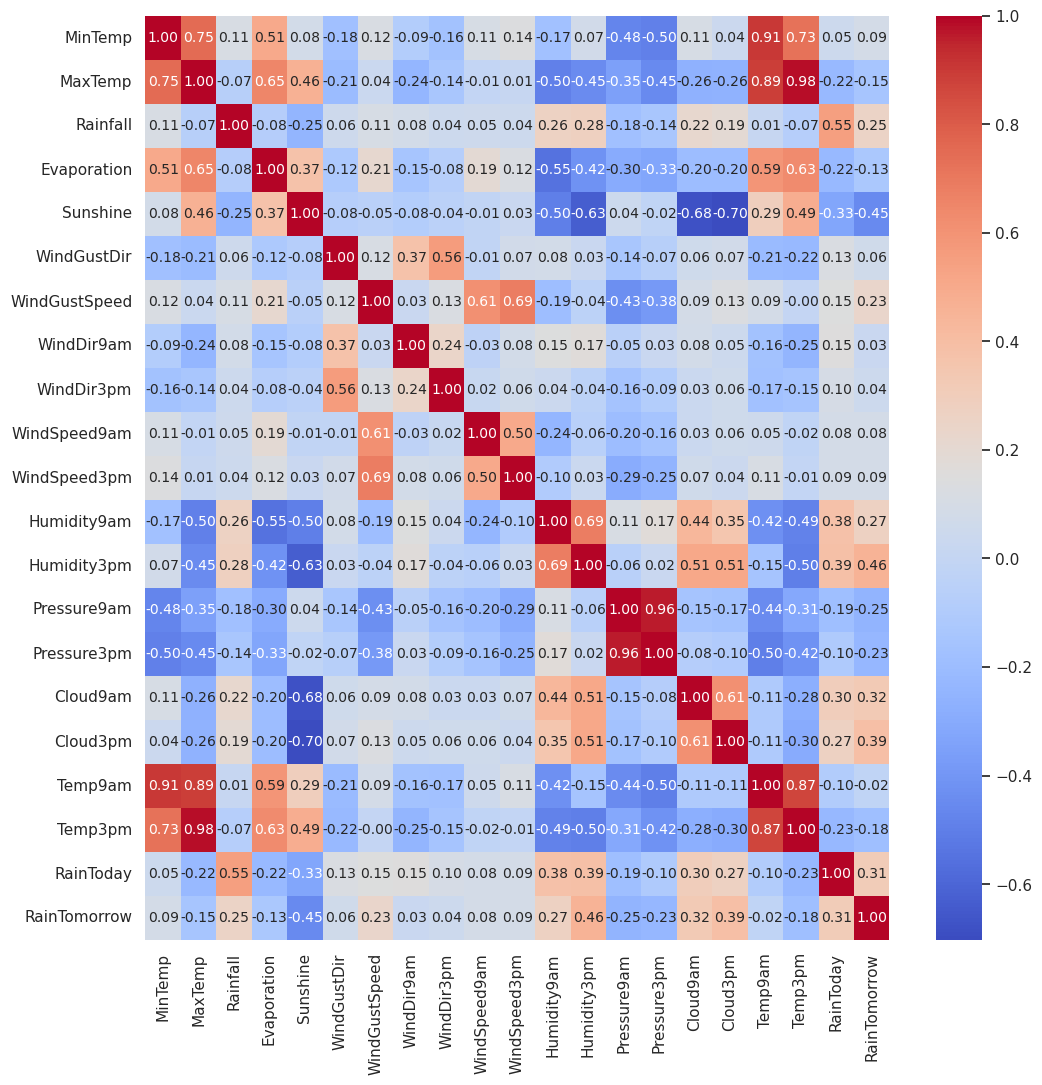

In [102]:
# Eliminar la fecha y ubicación
df_corr = df.dropna()
df_corr = df_corr.drop(columns=['Date', 'Location'])
df_corr = encode_df(df_corr)

# Calcular la matriz de correlación
corr_matrix = df_corr.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.grid(False)
plt.show()

In [103]:
target_corr = corr_matrix['RainTomorrow']

top_5_positive = target_corr.sort_values(ascending=False).head(6)
top_5_positive = top_5_positive.drop('RainTomorrow')
top_5_negative = target_corr.sort_values(ascending=True).head(5)

print("Top 5 variables con la mayor correlación positiva con 'RainTomorrow':")
print(top_5_positive)

print("\nTop 5 variables con la mayor correlación negativa con  'RainTomorrow':")
print(top_5_negative)

Top 5 variables con la mayor correlación positiva con 'RainTomorrow':
Humidity3pm    0.455358
Cloud3pm       0.388574
Cloud9am       0.323972
RainToday      0.309098
Humidity9am    0.271033
Name: RainTomorrow, dtype: float64

Top 5 variables con la mayor correlación negativa con  'RainTomorrow':
Sunshine      -0.453407
Pressure9am   -0.254816
Pressure3pm   -0.230418
Temp3pm       -0.183586
MaxTemp       -0.147467
Name: RainTomorrow, dtype: float64


------
## 4. Entrenamiento de modelos 

- **Elección de modelos**: Dado que queremos predecir un evento específico (lluvia o no lluvia), el enfoque es de clasificación binaria. Los modelos a considerar incluyen regresión logística, árboles de decisión, random forest, SVM, redes neuronales, métodos de ensamblado, entre otros. Vamos a elegir:
    * Random Forest:
        * Descripción: Un conjunto de árboles de decisión que mejora la precisión y reduce el sobreajuste mediante la combinación de múltiples árboles.
        * Ventaja: Mayor precisión y robustez comparado con un solo árbol de decisión.
    * XGBoost:
        * Descripción: Método de ensamblado que construyen modelos de árboles de decisión en etapas sucesivas, corrigiendo los errores de modelos anteriores.
        * Ventaja: Alta precisión y capacidad de manejo de características no lineales.
    * Árbol de Decisión:
        * Descripción: Utiliza un conjunto de reglas binarias para calcular una decisión final. 
        * Ventaja: Fácil de interpretar y entender. Puede manejar tanto datos numéricos como categóricos y no requiere de escalado de características.
    * Descartamos Support Vector Machines (SVM) por su complejidad computacional
- **Evaluación de los modelos**: 
    * Métricas: vamos a evaluar y comparar el rendimiento de los modelos con las siguientes métricas:
        * Recall (Sensibilidad): Mide la proporción de verdaderos positivos identificados correctamente sobre el total de positivos reales. Es importante en nuestro caso porque el costo de perder casos positivos (falsos negativos, predecimos que no va llover al día siguiente y sí llueve) es alto. 
        * F1-Score: Es la media armónica entre la precisión y el recall. Es útil en problemas desbalanceados porque considera tanto los falsos positivos como los falsos negativos.
        * AUC: Mide la capacidad de un modelo de clasificación binaria para distinguir entre las clases positivas y negativas a lo largo de todos los umbrales de clasificación posibles. 
        * No vamos a usar a la precisión (accuracy) porque no es una métrica adecuada para problemas de clasificación con datos desbalanceados.
    * Validación Cruzada: Vamos a implementar validación cruzada para asegurar que los modelos generalizan bien a datos no vistos.
    * Ajuste de Hiperparámetros: Vamos a optimizar los hiperparámetros de los modelos para mejorar su rendimiento.

-----

### Separación de datos

In [104]:
# Separamos los datos en conjuntos de entrenamiento y prueba

# Separacion del dataframe eliminando las observaciones con missings
df_dropna = df.dropna()
df_dropna_encoded = encode_df(df_dropna)
X_dropna = df_dropna_encoded.drop(columns=['RainTomorrow'])
y_dropna = df_dropna_encoded['RainTomorrow']
X_train_dropna, X_test_dropna, y_train_dropna, y_test_dropna = train_test_split(X_dropna, y_dropna, test_size=0.2, random_state=42, stratify=y_dropna)

# Separacion del dataframe imputando los missings
df_imputed_encoded = encode_df(df_imputed)
X_imputed = df_imputed_encoded.drop(columns=['RainTomorrow'])
y_imputed = df_imputed_encoded['RainTomorrow']
X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split(X_imputed, y_imputed, test_size=0.2, random_state=42, stratify=y_imputed)

En la separación de datos usamos la opción de `stratify` porque las clases están muy desbalanceadas:

In [105]:
print("Proporciones de clases antes de train_test_split:")
print("------------------------------------------------")
unique_original, counts_original = pd.Series(y_dropna).value_counts(normalize=True).index, pd.Series(y_dropna).value_counts(normalize=True).values
for u, c in zip(unique_original, counts_original):
    print(f'Class {u}: {c * 100:.2f}%')

print("\nProporciones de clases en el conjunto de entrenamiento:")
print("--------------------------------------------------------")
unique_train, counts_train = pd.Series(y_train_dropna).value_counts(normalize=True).index, pd.Series(y_train_dropna).value_counts(normalize=True).values
for u, c in zip(unique_train, counts_train):
    print(f'Class {u}: {c * 100:.2f}%')


# Calculo de scale_pos_weight para XGBoost: rsum(negative instances) / sum(positive instances)
target_class_counts = df['RainTomorrow'].value_counts()
scale_pos_weight = target_class_counts.loc["No"] / target_class_counts.loc["Yes"] 
print("\nProporcion de clases (parametro para entrenar XGBoost):")
print("--------------------------------------------------------")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Proporciones de clases antes de train_test_split:
------------------------------------------------
Class 0: 77.97%
Class 1: 22.03%

Proporciones de clases en el conjunto de entrenamiento:
--------------------------------------------------------
Class 0: 77.97%
Class 1: 22.03%

Proporcion de clases (parametro para entrenar XGBoost):
--------------------------------------------------------
scale_pos_weight = 3.46


-----

### Optimización de hiperparámetros

Vamos a optimizar los hiperparámetros para los tres modelos elegidos usando `recall`
como métrica ya que es importante para nuestro problema de negocio.

* **Decision Tree** y **Random Forest**
    - `max_depth`: Define la profundidad máxima de los árboles. Controla la complejidad del modelo, donde árboles más profundos pueden capturar patrones más complejos pero también corren el riesgo de overfitting.
    - `min_samples_split`: Es el número mínimo de muestras necesarias para dividir un nodo. Un valor bajo permite que el modelo sea más detallado, pero puede llevar a overfitting.
    - `min_samples_leaf`: Determina el número mínimo de muestras que debe tener una hoja del árbol. Valores bajos permiten que el modelo capture patrones muy específicos, aumentando la flexibilidad pero también el riesgo de overfitting.
    - `n_estimators` (solo Random Forest): Indica el número de árboles en el bosque. Un mayor número de árboles puede mejorar la precisión del modelo, pero también aumenta el tiempo de entrenamiento y el costo computacional.
* **XGBoost**
    - `n_estimators`: Número de árboles de decisión. Más árboles pueden mejorar el rendimiento pero aumentan el riesgo de overfitting.
    - `max_depth`: Profundidad máxima de cada árbol. Controla la complejidad del modelo, afectando directamente al overfitting y underfitting.
    - `learning_rate`: Tasa de aprendizaje. Determina el paso en cada actualización de los árboles. Valores más bajos requieren más árboles pero pueden mejorar la precisión.
    - `subsample`: Fracción de muestras utilizadas para entrenar cada árbol. Ayuda a prevenir el overfitting.

Como punto de partida vamos a crear un modelo baseline extremadamente simple que no toma en cuenta ninguna otra información meteorológica aparte de si llovió hoy para establecer un punto de referencia mínimo de rendimiento.

In [8]:
# Cargamos el dataset
df_baseline = pd.read_csv("weatherAUS.csv")
df_baseline['RainToday'] = df_baseline['RainToday'].map({'Yes': 1, 'No': 0})
df_baseline['RainTomorrow'] = df_baseline['RainTomorrow'].map({'Yes': 1, 'No': 0})
df_baseline.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)

# Prediccion: si llovio hoy, llueve mañana
df_baseline['PredictedRainTomorrow'] = df_baseline['RainToday']

# Calculamos las metricas del modelo baseline
accuracy = accuracy_score(df_baseline['RainTomorrow'], df_baseline['PredictedRainTomorrow'])
recall = recall_score(df_baseline['RainTomorrow'], df_baseline['PredictedRainTomorrow'])
f1 = f1_score(df_baseline['RainTomorrow'], df_baseline['PredictedRainTomorrow'])
balanced_accuracy = balanced_accuracy_score(df_baseline['RainTomorrow'], df_baseline['PredictedRainTomorrow'])

print("Metricas del modelo baseline:")
print(f"- Accuracy: {accuracy:.2f}")
print(f"- Recall: {recall:.2f}")
print(f"- F1-Score: {f1:.2f}")
print(f"- Balanced accuracy: {balanced_accuracy:.2f}")

print("\nClassification report del modelo baseline para ver las metricas para cada clase:")
print(classification_report(df_baseline['RainTomorrow'], df_baseline['PredictedRainTomorrow']))

Metricas del modelo baseline:
- Accuracy: 0.76
- Recall: 0.47
- F1-Score: 0.47
- Balanced accuracy: 0.66

Classification report del modelo baseline para ver las metricas para cada clase:
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85    109586
         1.0       0.46      0.47      0.47     31201

    accuracy                           0.76    140787
   macro avg       0.66      0.66      0.66    140787
weighted avg       0.76      0.76      0.76    140787



* Observaciones:
    - Si bien el modelo baseline parece tener una precisión general aceptable (76%) su capacidad para predecir correctamente los días de lluvia (clase 1) es limitada.
    - El dataset tiene un claro desbalance, con muchos más días sin lluvia (109586) que con lluvia (31201).
    - El recall para la clase 1 (lluvia) es de solo 47%, lo que significa que el modelo está fallando en identificar correctamente casi la mitad de los días lluviosos, lo cual es problemático porque es nuestro objetivo principal
    - El Recall mínimo que deberíamos obtener con los modelos elegidos es de 0.47.

--------

In [107]:
# Funcion para buscar los mejores hiperparámetros para un modelo dado, utilizando
# Grid Search u Optuna, basado en un conjunto de datos y un método de puntuación
def buscar_hiperparametros(modelo, espacio_hiperparametros, X, y, metodo='grid_search', cv=3, scoring='recall', n_trials=20):
    if metodo == 'grid_search':
        grid_search = GridSearchCV(estimator=modelo, param_grid=espacio_hiperparametros, cv=cv, n_jobs=-1, verbose=0, scoring=scoring)
        grid_search.fit(X, y)
        return grid_search.best_params_, grid_search.best_score_

    elif metodo == 'optuna':
        def objective(trial):
            hiperparametros = {
                k: trial.suggest_int(k, *v) if k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
                else trial.suggest_float(k, *v) for k, v in espacio_hiperparametros.items()
            }
            modelo.set_params(**hiperparametros)
            return cross_val_score(modelo, X, y, cv=cv, n_jobs=-1, scoring=scoring).mean()

        study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials)
        return study.best_params, study.best_value


# Funcion para imprimir los resultados de la búsqueda de hiperparámetros
def imprimir_resultados(modelo_nombre, mejores_hiperparametros, mejor_puntuacion):
    print(f"**{modelo_nombre}**")
    print(f"Mejores hiperparámetros: {mejores_hiperparametros}")
    print(f"Mejor puntuación: {mejor_puntuacion:.4f}")
    print("-" * 60)


# Funcion para aplicar la búsqueda de hiperparámetros a varios modelos
def buscar_hiperparametros_all_models(X_train, y_train):
    optuna.logging.set_verbosity(optuna.logging.ERROR)
    best_hiper = {}

    # DecisionTree con GridSearch
    modelo_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    espacio_dt_gs = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    mejores_hiper_dt_gs, mejor_puntuacion_dt_gs = buscar_hiperparametros(modelo_dt, espacio_dt_gs, X_train, y_train, metodo='grid_search', scoring='recall')
    imprimir_resultados("DecisionTree con Grid Search", mejores_hiper_dt_gs, mejor_puntuacion_dt_gs)

    # DecisionTree con Optuna
    modelo_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    espacio_dt_optuna = {
        'max_depth': (1, 32),
        'min_samples_split': (2, 64),
        'min_samples_leaf': (1, 64)
    }
    mejores_hiper_dt_optuna, mejor_puntuacion_dt_optuna = buscar_hiperparametros(modelo_dt, espacio_dt_optuna, X_train, y_train, metodo='optuna', scoring='recall')
    imprimir_resultados("DecisionTree con Optuna", mejores_hiper_dt_optuna, mejor_puntuacion_dt_optuna)
    best_hiper["dt"] = mejores_hiper_dt_optuna

    ############################################################################

    # RandomForest con Optuna
    modelo_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
    espacio_rf_optuna = {
        'n_estimators': (50, 300),
        'max_depth': (10, 100),
        'min_samples_split': (2, 20),
        'min_samples_leaf': (1, 10)
    }
    mejores_hiper_rf_optuna, mejor_puntuacion_rf_optuna = buscar_hiperparametros(modelo_rf, espacio_rf_optuna, X_train, y_train, metodo='optuna', scoring='recall')
    imprimir_resultados("Random Forest con Optuna", mejores_hiper_rf_optuna, mejor_puntuacion_rf_optuna)
    best_hiper["rf"] = mejores_hiper_rf_optuna

    ############################################################################

    # XGBClassifier con Optuna
    modelo_xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
    espacio_xgb_optuna = {
        'n_estimators': (50, 300),
        'max_depth': (3, 9),
        'learning_rate': (0.01, 0.2),
        'subsample': (0.5, 0.9)
    }
    mejores_hiper_xgb_optuna, mejor_puntuacion_xgb_optuna = buscar_hiperparametros(modelo_xgb, espacio_xgb_optuna, X_train, y_train, metodo='optuna', scoring='recall')
    imprimir_resultados("XGBoost con Optuna", mejores_hiper_xgb_optuna, mejor_puntuacion_xgb_optuna)
    best_hiper["xgb"] = mejores_hiper_xgb_optuna

    return best_hiper

print("Busqueda de hiperparametros para todos los modelos usando el dataset sin las observaciones con missings\n")
best_hiper_dropna = buscar_hiperparametros_all_models(X_train_dropna, y_train_dropna)

print("\nBusqueda de hiperparametros para todos los modelos usando el dataset imputado\n")
best_hiper_imputed = buscar_hiperparametros_all_models(X_train_imputed, y_train_imputed)

Busqueda de hiperparametros para todos los modelos usando el dataset sin las observaciones con missings

**DecisionTree con Grid Search**
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor puntuación: 0.7710
------------------------------------------------------------
**DecisionTree con Optuna**
Mejores hiperparámetros: {'max_depth': 2, 'min_samples_split': 56, 'min_samples_leaf': 39}
Mejor puntuación: 0.8065
------------------------------------------------------------
**Random Forest con Optuna**
Mejores hiperparámetros: {'n_estimators': 185, 'max_depth': 47, 'min_samples_split': 10, 'min_samples_leaf': 10}
Mejor puntuación: 0.7386
------------------------------------------------------------
**XGBoost con Optuna**
Mejores hiperparámetros: {'n_estimators': 198, 'max_depth': 3, 'learning_rate': 0.1254335218612733, 'subsample': 0.5682096494749166}
Mejor puntuación: 0.8025
------------------------------------------------------------

Busqueda 

* Observaciones:
    * Decision Tree y XGBoost demuestran ser los modelos de mejor rendimiento entre los evaluados.
    * La variabilidad en las configuraciones óptimas de hiperparámetros entre los dos conjuntos de datos demuestra la importancia de realizar una búsqueda de hiperparámetros específica para cada dataset.
    * La disminución en el rendimiento de los modelos en el dataset con valores imputados sugiere que la estrategia de imputación puede tener un impacto significativo y debe ser cuidadosamente considerada y evaluada.
    * No utilizamos Grid Search para RandomForest y XGBoost porque en las pruebas que hicimos obtuvimos resultados similares con Optuna y con mucho menor costo computacional

----

### Evaluación de los modelos

Vamos a evaluar los modelos elegidos utilizando validación cruzada para medir su rendimiento mediante las métricas de recall y F1_Score. 
La validación cruzada nos permite obtener una estimación más precisa y generalizable de su capacidad de predicción.

In [108]:
# Función para evaluar los distintos modelos
def evaluate_models(df, models, cv=5):
    df = df.copy()

    X = df.drop(columns=['RainTomorrow'])
    y = df['RainTomorrow']

    metrics_list = []
    for name, model in models.items():
        metrics = {"Model": name}

        start_time = time.time()
        for scoring_name, scorer in [
            ('Recall', make_scorer(recall_score)),
            ('F1_Score', make_scorer(f1_score))]:
            print(f"Evaluando {name} {scoring_name}...")
            cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
            metrics[scoring_name + '_mean'] = cv_scores.mean()
            metrics[scoring_name + '_var'] = cv_scores.var()

        fit_time = time.time() - start_time
        metrics['Fit_Time'] = fit_time

        metrics_list.append(metrics)

    metrics = pd.DataFrame(metrics_list)
    print(f"\nMetricas con validacion cruzada de {cv} folds:")
    display(metrics)
    return metrics

In [109]:
# Evaluamos los distintos modelos para el dataframe sin imputar
# Configuramos las versiones optimizadas con los hiperparametros encontrados en el punto anterior
df_dropna_enc = encode_df(df.dropna())

models_df_dropna = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', 
        random_state=42),
    "Decision Tree Optimizado": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        **best_hiper_dropna["dt"]),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', 
        random_state=42),
    "Random Forest Optimizado": RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        **best_hiper_dropna["rf"]),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight, 
        random_state=42),
    "XGBoost Optimizado": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        **best_hiper_dropna["xgb"]),
}

df_dropna_metrics = evaluate_models(df_dropna_enc, models_df_dropna)

Evaluando Decision Tree Recall...
Evaluando Decision Tree F1_Score...
Evaluando Decision Tree Optimizado Recall...
Evaluando Decision Tree Optimizado F1_Score...
Evaluando Random Forest Recall...
Evaluando Random Forest F1_Score...
Evaluando Random Forest Optimizado Recall...
Evaluando Random Forest Optimizado F1_Score...
Evaluando XGBoost Recall...
Evaluando XGBoost F1_Score...
Evaluando XGBoost Optimizado Recall...
Evaluando XGBoost Optimizado F1_Score...

Metricas con validacion cruzada de 5 folds:


,Model,Recall_mean,Recall_var,F1_Score_mean,F1_Score_var,Fit_Time
0,Decision Tree,0.513722,0.000548,0.510956,0.000260,5.935329
1,Decision Tree Optimizado,0.819674,0.001829,0.537032,0.001156,0.857536
2,Random Forest,0.460051,0.001027,0.570996,0.000408,72.871662
3,Random Forest Optimizado,0.715299,0.000354,0.645937,0.000573,105.094157
4,XGBoost,0.721176,0.001141,0.631128,0.000494,3.733230
5,XGBoost Optimizado,0.784985,0.000442,0.637106,0.000839,4.899258


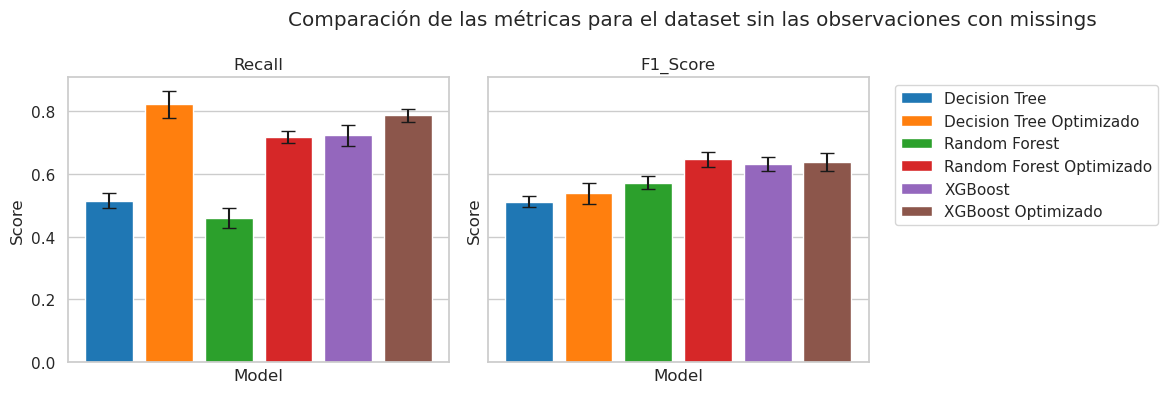

In [110]:
# Graficamos las métricas
def plot_metrics(df, df_name):
    palette = sns.color_palette("tab10", n_colors=len(df['Model'].unique()))

    fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for i, metric in enumerate(['Recall', 'F1_Score']):
        means = df[f'{metric}_mean']
        errors = np.sqrt(df_dropna_metrics[f'{metric}_var'])
        x = np.arange(len(means))

        for idx, color in enumerate(palette):
            axs[i].bar(x[idx], means[idx], yerr=errors[idx], capsize=5, color=color, label=df['Model'][idx])

        axs[i].set_title(f'{metric}')
        axs[i].set_xlabel('Model')
        axs[i].set_ylabel('Score')
        axs[i].set_xticks([])

    plt.suptitle(f'Comparación de las métricas para el {df_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


plot_metrics(df_dropna_metrics, "dataset sin las observaciones con missings")

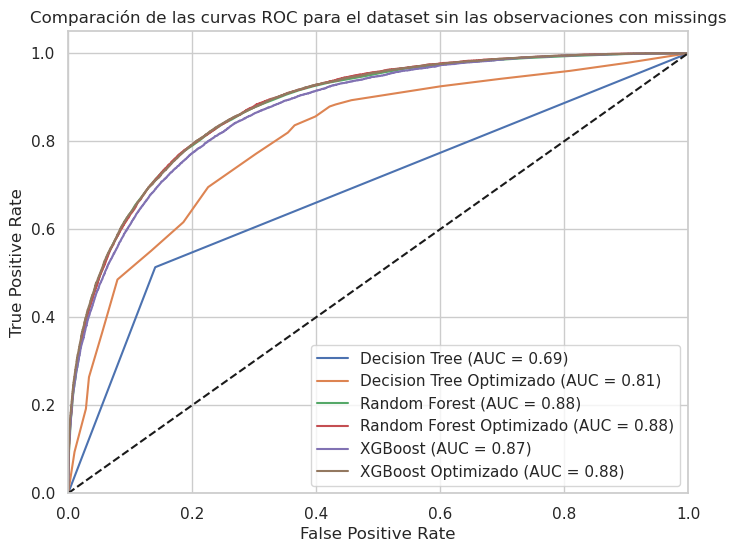

In [111]:
# Graficamos las curvas ROC
def plot_curva_roc(df, models, df_name, cv=5):
    df = df.copy()
    X = df.drop(columns=['RainTomorrow'])
    y = df['RainTomorrow']

    plt.figure(figsize=(8, 6))

    for name, model in models.items():
        y_probs = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

        fpr, tpr, thresholds = roc_curve(y, y_probs)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Comparación de las curvas ROC para el {df_name}')
    plt.legend(loc="lower right")
    plt.show()


plot_curva_roc(df_dropna_enc, models_df_dropna, "dataset sin las observaciones con missings")


* Análisis de los resultados:
    * La optimización de hiperparámetros mejora notablemente el Recall para todos los modelos
    * Las mejoras en el F1 Score son más moderadas ya que la métrica utilizada para optimizar los hiperparámetros fue el Recall
    * El tiempo de ajuste varía entre los modelos, lo que sugiere que los hiperparámetros optimizados pueden mejorar no solo el rendimiento del modelo sino también su eficiencia computacional
    * XGBoost, tanto en su versión estándar como optimizada, muestra un buen equilibrio entre Recall, F1 Score (teniendo en cuenta su media y varianza), AUC y eficiencia computacional

-------

Evaluando Decision Tree Recall...
Evaluando Decision Tree F1_Score...
Evaluando Decision Tree Optimizado Recall...
Evaluando Decision Tree Optimizado F1_Score...
Evaluando Random Forest Recall...
Evaluando Random Forest F1_Score...
Evaluando Random Forest Optimizado Recall...
Evaluando Random Forest Optimizado F1_Score...
Evaluando XGBoost Recall...
Evaluando XGBoost F1_Score...
Evaluando XGBoost Optimizado Recall...
Evaluando XGBoost Optimizado F1_Score...

Metricas con validacion cruzada de 5 folds:


,Model,Recall_mean,Recall_var,F1_Score_mean,F1_Score_var,Fit_Time
0,Decision Tree,0.486275,0.000438,0.488836,0.000215,23.008906
1,Decision Tree Optimizado,0.757631,0.000541,0.580177,0.000440,14.613066
2,Random Forest,0.435456,0.000800,0.549707,0.000172,262.898489
3,Random Forest Optimizado,0.693102,0.001267,0.632346,0.000591,603.769215
4,XGBoost,0.749851,0.000723,0.621279,0.000377,9.003065
5,XGBoost Optimizado,0.781723,0.000741,0.620117,0.000603,11.149510


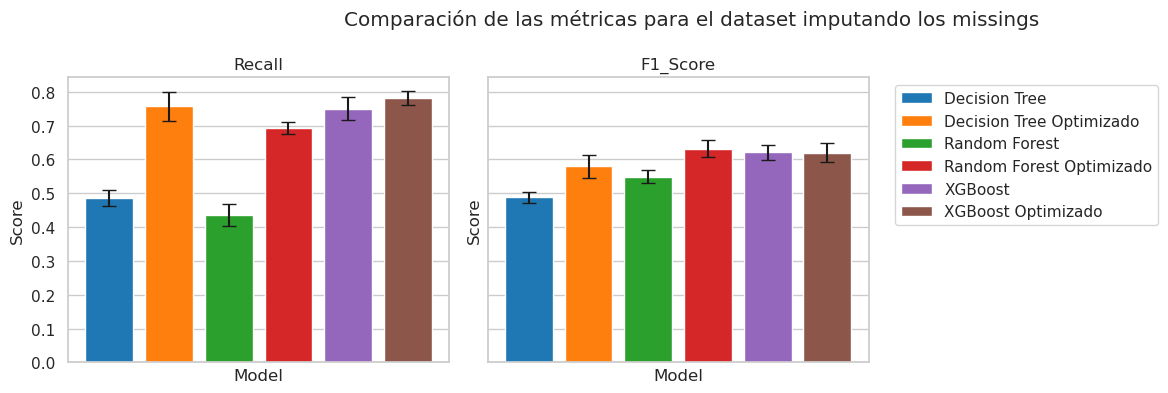

In [112]:
# Ahora evaluamos los distintos modelos para el dataframe imputado
df_imputed_enc = encode_df(df_imputed)

models_df_imputed = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', 
        random_state=42),
    "Decision Tree Optimizado": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        **best_hiper_imputed["dt"]),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', 
        random_state=42),
    "Random Forest Optimizado": RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        **best_hiper_imputed["rf"]),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', 
        scale_pos_weight=scale_pos_weight, 
        random_state=42),
    "XGBoost Optimizado": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        **best_hiper_imputed["xgb"]),
}

df_imputed_metrics = evaluate_models(df_imputed_enc, models_df_imputed)

plot_metrics(df_imputed_metrics, "dataset imputando los missings")

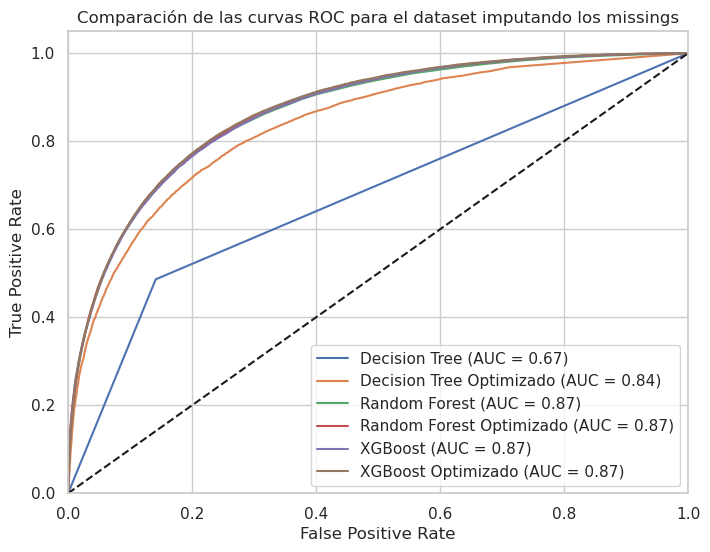

In [114]:
plot_curva_roc(df_imputed_enc, models_df_imputed, "dataset imputando los missings")


Los resultados son muy similares a los del dataset eliminando las observaciones con missings pero con mucho peor tiempo de entrenamiento debido al tamaño del dataset. 

-------------

Intentamos reducir la dimensión del dataset imputado mediante PCA pero no obtuvimos mejores resultados y el tiempo de entrenamiento empeoró, posiblemente por la complejidad de los datos transformados.
Dejamos como referencia solo el código de la reducción dimensional:

In [113]:
df_pca = encode_df(df_imputed)
print(f"Cantidad de dimensiones antes de PCA: {df_pca.shape[1]}")
pca_target = df_pca['RainTomorrow']
pca_features = df_pca.drop(columns=['RainTomorrow'])
scaler = StandardScaler()
pca_features_scaled = scaler.fit_transform(pca_features)

# Aplicamos PCA para retener el 95% de la varianza
pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(pca_features_scaled)
df_pca = pd.DataFrame(pca_features)
df_pca['RainTomorrow'] = pca_target

print(f"Cantidad de dimensiones después de PCA: {df_pca.shape[1]}")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.4f}")

Cantidad de dimensiones antes de PCA: 33
Cantidad de dimensiones después de PCA: 23
Varianza total explicada: 0.9546


------

## 5. Conclusiones

* La investigación sobre la búsqueda de hiperparámetros y evaluación de modelos en distintos datasets revela información valiosa sobre cómo diferentes modelos y sus configuraciones óptimas interactúan con los datos. La superioridad de las versiones optimizadas de los modelos sugieren que la optimización de hiperparámetros es un paso crucial para mejorar el rendimiento.
* La variabilidad en el rendimiento entre los datasets muestra la importancia de una cuidadosa preparación y manejo de los datos.
* Vimos que la elección del modelo no solo depende de la precisión en las métricas de evaluación sino también de consideraciones prácticas como el tiempo de ajuste y la capacidad de generalización del modelo. La optimización de hiperparámetros muestra ser efectiva para mejorar el rendimiento, pero también introduce complejidad adicional y costos computacionales.

* Propuestas para futuras investigaciones:
    * Exploración de otros métodos de imputación: Dado el impacto significativo de la imputación de valores faltantes en el rendimiento del modelo, investigar métodos de imputación más avanzados o personalizados podría ofrecer mejoras en la precisión del modelo.
    * Evaluación de modelos en escenarios de mundo real: Extender la evaluación de modelos a conjuntos de datos más grandes y diversos, posiblemente en escenarios de mundo real, para comprender mejor su capacidad de generalización y robustez.
    * Incorporación de técnicas de aprendizaje profundo: Explorar modelos de aprendizaje profundo, que pueden capturar relaciones no lineales complejas y patrones en los datos de manera más efectiva que los modelos tradicionales.